In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, chi2_contingency
from config import FEATURE_DATA_PATH, PROCESSED_DATA_DIR

df = pd.read_csv(FEATURE_DATA_PATH, index_col=0)
print(f'Shape: {df.shape}')
df.head()

Shape: (1284, 21)


,start_time,end_time,time_control,rated,opening_family,num_moves,avg_time_per_move,player_color,player_rating,opponent_rating,...,result_method,rating_change,duration (seconds),eco_category,time_of_day_bin,rating_diff,time_from_the_last_game,game_played_in_the_same_day,last achieved 3-game win streak,last suffered 3-game loss streak
0,2025-01-02 05:55:56,2025-01-02 06:01:32,600,True,Mieses Opening,63,5.226667,black,1093,1374,...,Abandon,0,336.0,A,03-06,-281,NaN,0,0,0
1,2025-02-10 05:23:10,2025-02-10 05:31:45,600,True,Queens Pawn Opening,39,12.436842,white,1217,1078,...,Resign,124,515.0,D,03-06,139,56121.633333,0,0,0
2,2025-02-10 05:31:58,2025-02-10 05:44:51,600,True,French Defense,70,17.250000,black,1308,1202,...,Resign,91,773.0,C,03-06,106,0.216667,1,0,0
3,2025-02-14 05:37:00,2025-02-14 05:50:33,600,True,Sicilian Defense,75,10.664865,white,1383,1306,...,Resign,75,813.0,B,03-06,77,5752.150000,0,0,0
4,2025-02-14 05:50:45,2025-02-14 06:00:07,600,True,Queens Gambit,45,14.976190,black,1308,1316,...,Checkmate,-75,562.0,D,03-06,-8,0.200000,1,1,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1284 entries, 0 to 1283
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   start_time                        1284 non-null   str    
 1   end_time                          1284 non-null   str    
 2   time_control                      1284 non-null   str    
 3   rated                             1284 non-null   bool   
 4   opening_family                    1284 non-null   str    
 5   num_moves                         1284 non-null   int64  
 6   avg_time_per_move                 1284 non-null   float64
 7   player_color                      1284 non-null   str    
 8   player_rating                     1284 non-null   int64  
 9   opponent_rating                   1284 non-null   int64  
 10  player_result                     1284 non-null   str    
 11  result_method                     1284 non-null   str    
 12  rating_change    

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
num_moves,1284.0,75.214953,35.244637,3.00,49.000000,71.000000,97.000000,217.000000
avg_time_per_move,1284.0,11.197197,4.255699,1.85,8.347839,10.662432,13.475379,34.380000
player_rating,1284.0,1360.235981,133.350251,1093.00,1239.000000,1343.000000,1492.000000,1617.000000
opponent_rating,1284.0,1358.478193,164.307779,246.00,1235.000000,1343.000000,1492.000000,2140.000000
rating_change,1284.0,0.370717,9.799452,-75.00,-8.000000,0.000000,8.000000,124.000000
duration (seconds),1284.0,755.787383,366.205313,18.00,496.000000,771.000000,1002.000000,3012.000000
rating_diff,1284.0,1.757788,90.506549,-648.00,-18.000000,1.000000,18.000000,1012.000000
time_from_the_last_game,1283.0,585.650325,3647.776373,0.05,0.866667,6.600000,385.075000,103685.166667
game_played_in_the_same_day,1284.0,3.112928,3.305045,0.00,1.000000,2.000000,4.000000,22.000000
last achieved 3-game win streak,1284.0,0.109813,0.312778,0.00,0.000000,0.000000,0.000000,1.000000


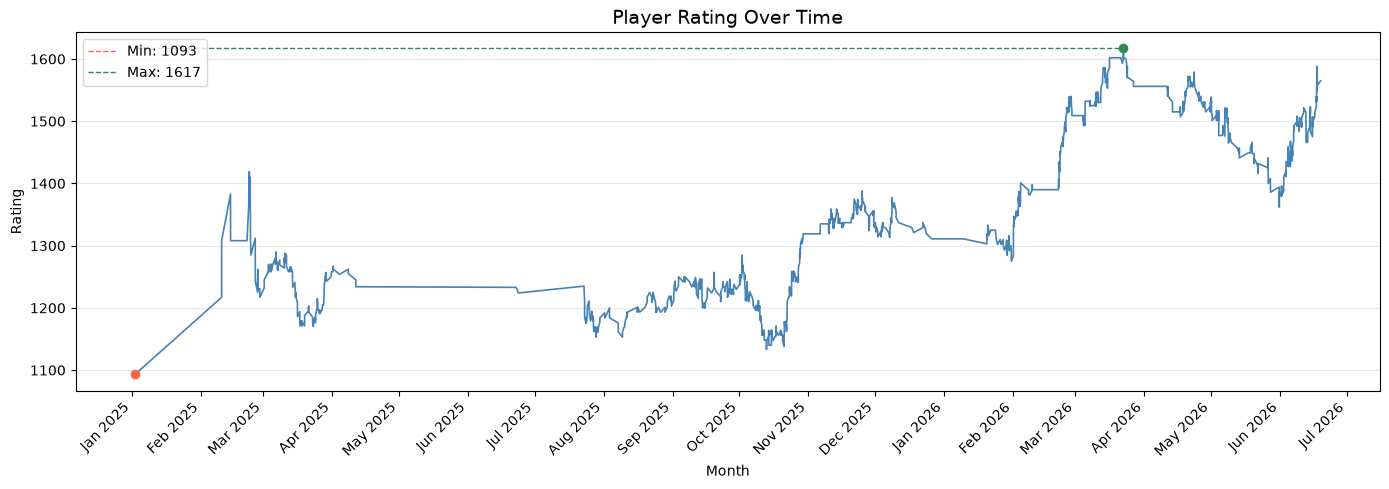

In [4]:

# Rating theo từng game
df_rating = df.copy()
df_rating['start_time'] = pd.to_datetime(df_rating['start_time'])

min_rating = df_rating['player_rating'].min()
max_rating = df_rating['player_rating'].max()
date_min = df_rating.loc[df_rating['player_rating'] == min_rating, 'start_time'].iloc[0]
date_max = df_rating.loc[df_rating['player_rating'] == max_rating, 'start_time'].iloc[0]
date_start = df_rating['start_time'].iloc[0]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_rating['start_time'], df_rating['player_rating'], linewidth=1.2, color='steelblue')

# Đường nét đứt từ đầu tới điểm min/max
ax.hlines(min_rating, date_start, date_min, colors='tomato', linestyles='--', linewidth=1, label=f'Min: {min_rating}')
ax.hlines(max_rating, date_start, date_max, colors='seagreen', linestyles='--', linewidth=1, label=f'Max: {max_rating}')

# Đánh dấu điểm min/max
ax.scatter([date_min], [min_rating], color='tomato', zorder=5)
ax.scatter([date_max], [max_rating], color='seagreen', zorder=5)

ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')

ax.set_title('Player Rating Over Time', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Rating')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [5]:

df_stat = df.copy()
df_stat['start_time'] = pd.to_datetime(df_stat['start_time'])
df_stat['date'] = df_stat['start_time'].dt.date

# Ngày chơi nhiều game nhất
busiest = df_stat.groupby('date').size()
busiest_date = busiest.idxmax()
busiest_count = int(busiest.max())

# Streak helper
def longest_streak(results, target):
    max_s = cur = 0
    for r in results:
        cur = cur + 1 if r in target else 0
        max_s = max(max_s, cur)
    return max_s

results = df_stat['player_result'].str.lower().tolist()
win_streak  = longest_streak(results, {'win'})
unbeaten    = longest_streak(results, {'win', 'draw'})
loss_streak = longest_streak(results, {'loss'})

wins   = df_stat[df_stat['player_result'].str.lower() == 'win']
losses = df_stat[df_stat['player_result'].str.lower() == 'loss']

r5 = wins.loc[wins['rating_diff'].idxmin()]
r6 = wins.loc[wins['opponent_rating'].idxmax()]
r7 = losses.loc[losses['rating_diff'].idxmax()]
r8 = losses.loc[losses['opponent_rating'].idxmin()]

def fmt(row):
    return (f"{int(row['player_rating'])} vs {int(row['opponent_rating'])} "
            f"(difference: {int(row['rating_diff'])})")

stats = [
    ("Ngày chơi nhiều game nhất",                              f"{busiest_date} ({busiest_count} games)"),
    ("Chuỗi thắng dài nhất",                                   f"{win_streak} games"),
    ("Chuỗi bất bại dài nhất",                                 f"{unbeaten} games"),
    ("Chuỗi thua dài nhất",                                    f"{loss_streak} games"),
    ("Thắng đối thủ có rating cao hơn và chênh lệch rating cao nhất",           fmt(r5)),
    ("Thắng với đối thủ có rating cao nhất",                   fmt(r6)),
    ("Thua đối thủ có rating thấp hơn và chênh lệch rating cao nhất",              fmt(r7)),
    ("Thua với đối thủ có rating thấp nhất",                   fmt(r8)),
]

table = pd.DataFrame(stats, columns=['Thống kê', 'Kết quả'])
table.index = range(1, len(table) + 1)
table


,Thống kê,Kết quả
1,Ngày chơi nhiều game nhất,2026-06-17 (23 games)
2,Chuỗi thắng dài nhất,9 games
3,Chuỗi bất bại dài nhất,11 games
4,Chuỗi thua dài nhất,8 games
5,Thắng đối thủ có rating cao hơn và chênh lệch ...,1509 vs 2140 (difference: -631)
6,Thắng với đối thủ có rating cao nhất,1509 vs 2140 (difference: -631)
7,Thua đối thủ có rating thấp hơn và chênh lệch ...,1308 vs 598 (difference: 710)
8,Thua với đối thủ có rating thấp nhất,1308 vs 598 (difference: 710)


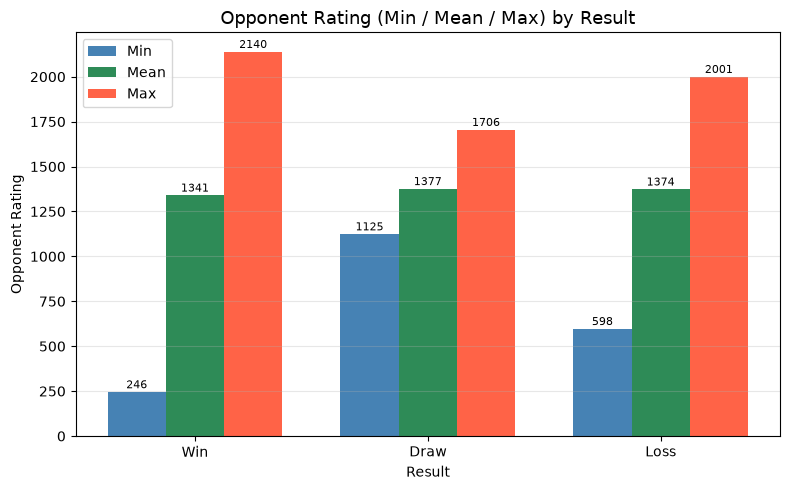

In [6]:

# Grouped bar: min/mean/max opponent_rating theo Win/Draw/Loss
df_bar = df.copy()
df_bar['result_label'] = df_bar['player_result'].str.capitalize()

agg = (df_bar.groupby('result_label')['opponent_rating']
       .agg(['min', 'mean', 'max'])
       .reindex(['Win', 'Draw', 'Loss']))

x = np.arange(len(agg))
width = 0.25
colors = ['steelblue', 'seagreen', 'tomato']
metrics = [('min', 'Min'), ('mean', 'Mean'), ('max', 'Max')]

fig, ax = plt.subplots(figsize=(8, 5))
for i, (col, label) in enumerate(metrics):
    bars = ax.bar(x + (i - 1) * width, agg[col], width=width, label=label, color=colors[i])
    for bar in bars:
        val = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, val + 5,
                f'{val:.0f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(agg.index)
ax.set_xlabel('Result')
ax.set_ylabel('Opponent Rating')
ax.set_title('Opponent Rating (Min / Mean / Max) by Result', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


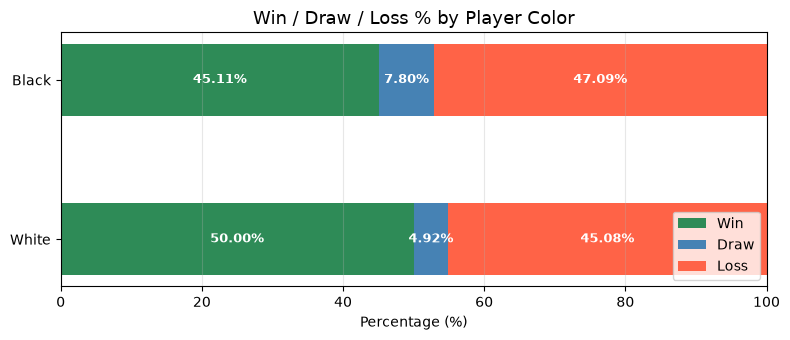

In [7]:

# Stacked horizontal bar: % Win/Draw/Loss theo màu quân
df_wdl = df.copy()
df_wdl['color_label'] = df_wdl['player_color'].str.capitalize()
df_wdl['result_label'] = df_wdl['player_result'].str.capitalize()

counts = (df_wdl.groupby(['color_label', 'result_label'])
          .size()
          .unstack(fill_value=0)
          [['Win', 'Draw', 'Loss']])
pct = counts.div(counts.sum(axis=1), axis=0) * 100
pct = pct.reindex(['White', 'Black'])

colors = ['seagreen', 'steelblue', 'tomato']
fig, ax = plt.subplots(figsize=(8, 3.5))
left = np.zeros(len(pct))
for col, color in zip(['Win', 'Draw', 'Loss'], colors):
    vals = pct[col].values
    bars = ax.barh(pct.index, vals, left=left, color=color, label=col, height=0.45)
    for bar, val in zip(bars, vals):
        if val >= 4:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:.2f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    left += vals

ax.set_xlim(0, 100)
ax.set_xlabel('Percentage (%)')
ax.set_title('Win / Draw / Loss % by Player Color', fontsize=13)
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


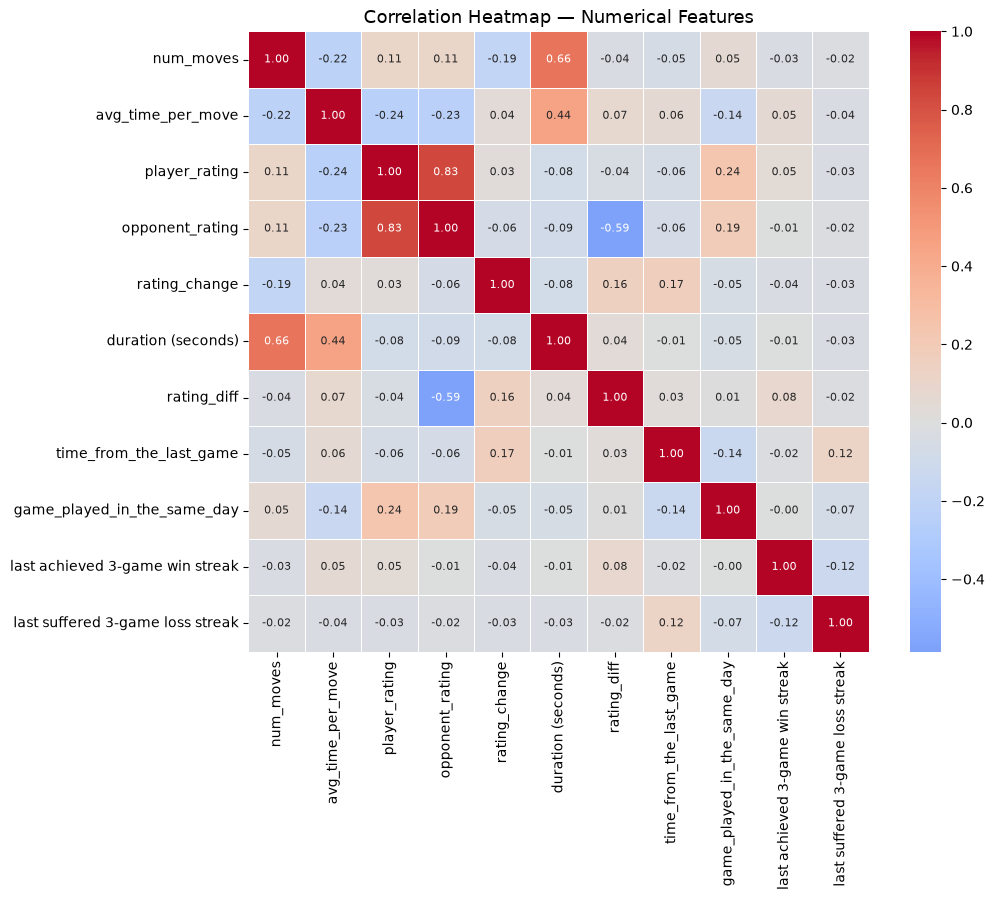

In [8]:

# Heatmap correlation cho numerical features
num_df = df.select_dtypes(include='number')
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='white', square=True, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=13)
plt.tight_layout()
plt.show()


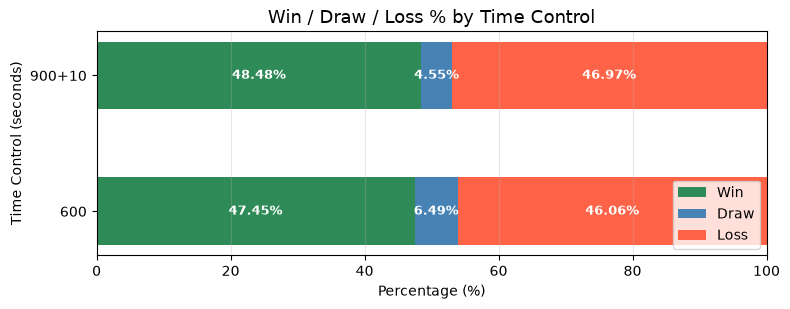

In [9]:

# Stacked horizontal bar: % Win/Draw/Loss theo time_control
df_tc = df.copy()
df_tc['result_label'] = df_tc['player_result'].str.capitalize()

counts = (df_tc.groupby(['time_control', 'result_label'])
          .size()
          .unstack(fill_value=0)
          [['Win', 'Draw', 'Loss']])
pct = counts.div(counts.sum(axis=1), axis=0) * 100

colors = ['seagreen', 'steelblue', 'tomato']
fig, ax = plt.subplots(figsize=(8, 0.6 * len(pct) + 2))
left = np.zeros(len(pct))
for col, color in zip(['Win', 'Draw', 'Loss'], colors):
    vals = pct[col].values
    bars = ax.barh(pct.index.astype(str), vals, left=left, color=color, label=col, height=0.5)
    for bar, val in zip(bars, vals):
        if val >= 4:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:.2f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    left += vals

ax.set_xlim(0, 100)
ax.set_xlabel('Percentage (%)')
ax.set_ylabel('Time Control (seconds)')
ax.set_title('Win / Draw / Loss % by Time Control', fontsize=13)
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


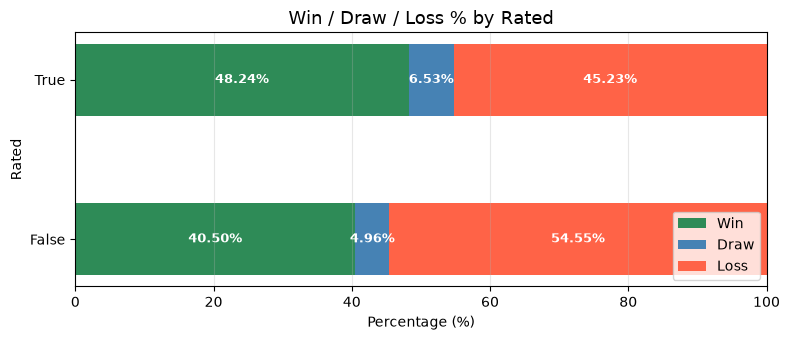

In [10]:

# Stacked horizontal bar: % Win/Draw/Loss theo rated
df_rated = df.copy()
df_rated['result_label'] = df_rated['player_result'].str.capitalize()

counts = (df_rated.groupby(['rated', 'result_label'])
          .size()
          .unstack(fill_value=0)
          [['Win', 'Draw', 'Loss']])
pct = counts.div(counts.sum(axis=1), axis=0) * 100

colors = ['seagreen', 'steelblue', 'tomato']
fig, ax = plt.subplots(figsize=(8, 3.5))
left = np.zeros(len(pct))
for col, color in zip(['Win', 'Draw', 'Loss'], colors):
    vals = pct[col].values
    bars = ax.barh(pct.index.astype(str), vals, left=left, color=color, label=col, height=0.45)
    for bar, val in zip(bars, vals):
        if val >= 4:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:.2f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    left += vals

ax.set_xlim(0, 100)
ax.set_xlabel('Percentage (%)')
ax.set_ylabel('Rated')
ax.set_title('Win / Draw / Loss % by Rated', fontsize=13)
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1284 entries, 0 to 1283
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   start_time                        1284 non-null   str    
 1   end_time                          1284 non-null   str    
 2   time_control                      1284 non-null   str    
 3   rated                             1284 non-null   bool   
 4   opening_family                    1284 non-null   str    
 5   num_moves                         1284 non-null   int64  
 6   avg_time_per_move                 1284 non-null   float64
 7   player_color                      1284 non-null   str    
 8   player_rating                     1284 non-null   int64  
 9   opponent_rating                   1284 non-null   int64  
 10  player_result                     1284 non-null   str    
 11  result_method                     1284 non-null   str    
 12  rating_change    

In [12]:

# % WDL theo time_of_day_bin (giờ Việt Nam, UTC+7)
df_tod = df.copy()
df_tod['result_label'] = df_tod['player_result'].str.capitalize()

hours_vn = (pd.to_datetime(df_tod['start_time']) + pd.Timedelta(hours=7)).dt.hour
labels = ['00-03', '03-06', '06-09', '09-12', '12-15', '15-18', '18-21', '21-00']
df_tod['time_of_day_bin'] = pd.Categorical(
    pd.cut(hours_vn, bins=[0,3,6,9,12,15,18,21,24], labels=labels, right=False),
    categories=labels, ordered=True
)

counts = (df_tod.groupby(['time_of_day_bin', 'result_label'], observed=True)
          .size()
          .unstack(fill_value=0))

for col in ['Win', 'Draw', 'Loss']:
    if col not in counts.columns:
        counts[col] = 0
counts = counts[['Win', 'Draw', 'Loss']]

total = counts.sum(axis=1)
pct = (counts.div(total, axis=0) * 100).round(2)
pct.columns = ['Win (%)', 'Draw (%)', 'Loss (%)']
pct.insert(2, 'Unbeaten (%)', (pct['Win (%)'] + pct['Draw (%)']).round(2))
pct.insert(0, 'Total Games', total)
pct.index.name = 'Time of Day (VN)'
pct


,Total Games,Win (%),Draw (%),Unbeaten (%),Loss (%)
Time of Day (VN),,,,,
00-03,5,0.00,40.00,40.00,60.00
06-09,97,48.45,7.22,55.67,44.33
09-12,211,45.02,2.37,47.39,52.61
12-15,129,56.59,9.30,65.89,34.11
15-18,318,45.91,7.55,53.46,46.54
18-21,223,51.57,4.93,56.50,43.50
21-00,301,44.52,6.98,51.50,48.50


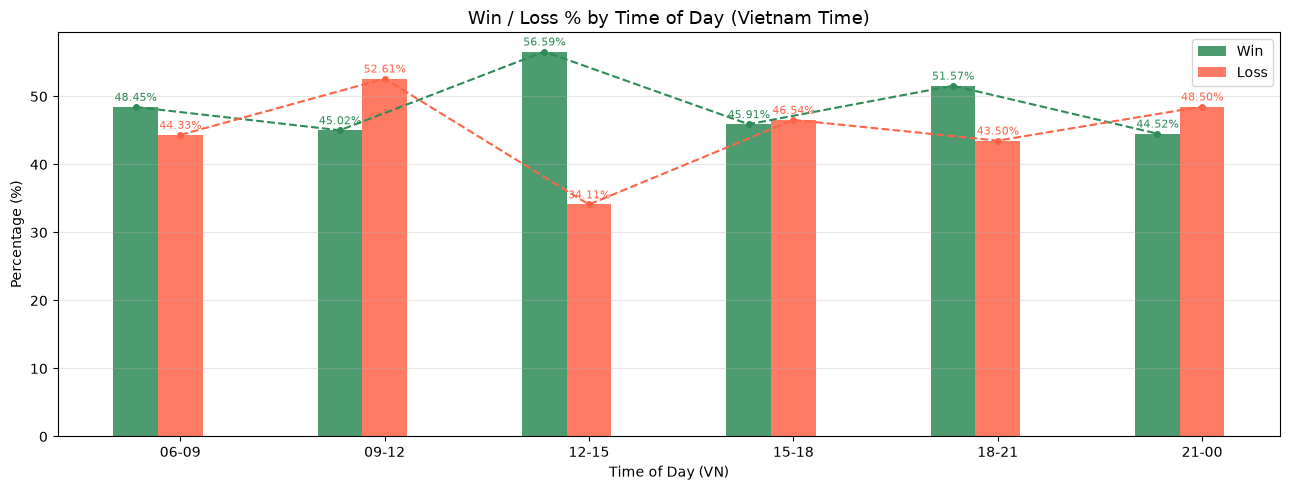

In [13]:

# Grouped bar + line: % WL theo time of day (VN, bỏ 00-03)
df_tod2 = df.copy()
df_tod2['result_label'] = df_tod2['player_result'].str.capitalize()
hours_vn = (pd.to_datetime(df_tod2['start_time']) + pd.Timedelta(hours=7)).dt.hour
labels = ['00-03', '03-06', '06-09', '09-12', '12-15', '15-18', '18-21', '21-00']
df_tod2['time_of_day_bin'] = pd.Categorical(
    pd.cut(hours_vn, bins=[0,3,6,9,12,15,18,21,24], labels=labels, right=False),
    categories=labels, ordered=True
)

counts = (df_tod2.groupby(['time_of_day_bin', 'result_label'], observed=True)
          .size().unstack(fill_value=0))
for col in ['Win', 'Draw', 'Loss']:
    if col not in counts.columns:
        counts[col] = 0

# Mẫu số là tổng cả 3 kết quả để khớp với table
total = counts[['Win', 'Draw', 'Loss']].sum(axis=1)
pct = (counts[['Win', 'Loss']].div(total, axis=0) * 100).round(2)
pct = pct.drop(index='00-03')

x = np.arange(len(pct)) * 1.6
width = 0.35
colors = ['seagreen', 'tomato']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (col, color) in enumerate(zip(['Win', 'Loss'], colors)):
    offsets = x + (i - 0.5) * width
    bars = ax.bar(offsets, pct[col], width=width, color=color, label=col, alpha=0.85)
    ax.plot(offsets, pct[col], color=color, marker='o', linewidth=1.5, markersize=4, linestyle='--')
    for bar, val in zip(bars, pct[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=8, color=color)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(pct.index)
ax.set_xlabel('Time of Day (VN)')
ax.set_ylabel('Percentage (%)')
ax.set_title('Win / Loss % by Time of Day (Vietnam Time)', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


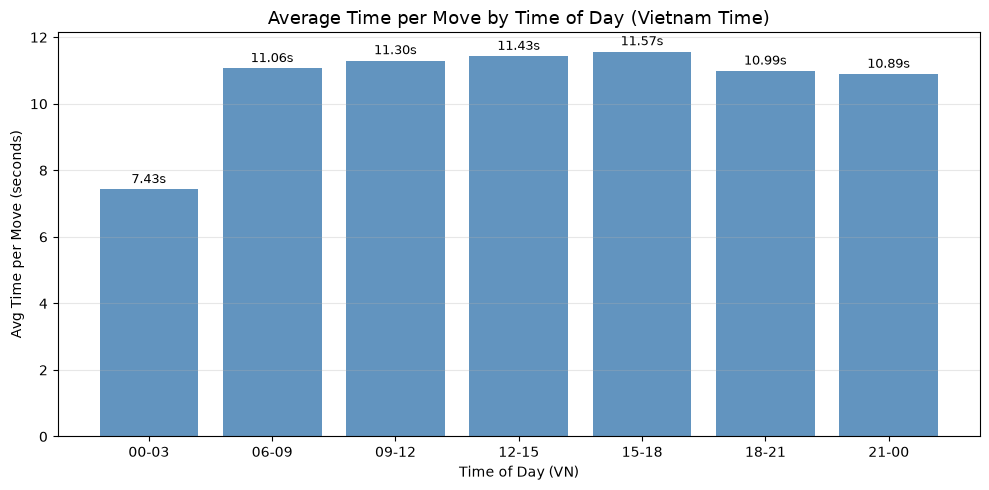

In [14]:

# Bar chart: avg_time_per_move trung bình theo time of day (VN)
df_atpm = df.copy()
hours_vn = (pd.to_datetime(df_atpm['start_time']) + pd.Timedelta(hours=7)).dt.hour
labels = ['00-03', '03-06', '06-09', '09-12', '12-15', '15-18', '18-21', '21-00']
df_atpm['time_of_day_bin'] = pd.Categorical(
    pd.cut(hours_vn, bins=[0,3,6,9,12,15,18,21,24], labels=labels, right=False),
    categories=labels, ordered=True
)

avg_atpm = df_atpm.groupby('time_of_day_bin', observed=True)['avg_time_per_move'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(avg_atpm.index, avg_atpm.values, color='steelblue', alpha=0.85)
for bar, val in zip(bars, avg_atpm.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{val:.2f}s', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Time of Day (VN)')
ax.set_ylabel('Avg Time per Move (seconds)')
ax.set_title('Average Time per Move by Time of Day (Vietnam Time)', fontsize=13)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [15]:

# Table: count, win rate, loss rate theo eco_category
df_eco = df.copy()
df_eco['is_win']  = (df_eco['player_result'].str.lower() == 'win').astype(int)
df_eco['is_loss'] = (df_eco['player_result'].str.lower() == 'loss').astype(int)

table_eco = (df_eco.groupby('eco_category')
             .agg(Count=('is_win', 'count'),
                  Win_Rate=('is_win', 'mean'),
                  Loss_Rate=('is_loss', 'mean'))
             .sort_index()
             .reset_index())

table_eco['Win Rate (%)']  = (table_eco['Win_Rate']  * 100).round(2)
table_eco['Loss Rate (%)'] = (table_eco['Loss_Rate'] * 100).round(2)
table_eco = table_eco[['eco_category', 'Count', 'Win Rate (%)', 'Loss Rate (%)']]
table_eco.columns = ['ECO Category', 'Count', 'Win Rate (%)', 'Loss Rate (%)']
table_eco


,ECO Category,Count,Win Rate (%),Loss Rate (%)
0,A,106,54.72,35.85
1,B,271,48.71,46.13
2,C,724,45.72,48.34
3,D,177,48.59,43.50
4,E,6,50.00,33.33


In [16]:
def opening_win_table(color, top=5):
    sub = df[df['player_color'].str.lower() == color].copy()
    sub['is_win']  = (sub['player_result'].str.lower() == 'win').astype(int)
    sub['is_loss'] = (sub['player_result'].str.lower() == 'loss').astype(int)
    t = (sub.groupby('opening_family')
         .agg(Count=('is_win', 'count'),
              Win_Rate=('is_win', 'mean'),
              Loss_Rate=('is_loss', 'mean'))
         .reset_index()
         .query('Count >= 15'))
    t['Win Rate (%)']  = (t['Win_Rate']  * 100).round(2)
    t['Loss Rate (%)'] = (t['Loss_Rate'] * 100).round(2)
    t = (t[['opening_family', 'Count', 'Win Rate (%)', 'Loss Rate (%)']]
         .sort_values('Win Rate (%)', ascending=False)
         .reset_index(drop=True))
    t.index += 1
    t.columns = ['Opening Family', 'Count', 'Win Rate (%)', 'Loss Rate (%)']
    return t.iloc[:top]

print('=== BLACK ===')
display(opening_win_table('black'))

print('=== WHITE ===')
display(opening_win_table('white'))


=== BLACK ===


,Opening Family,Count,Win Rate (%),Loss Rate (%)
1,Kings Gambit,23,56.52,43.48
2,Center Game,20,55.00,40.00
3,Nimzowitsch Defense,15,53.33,40.00
4,Scandinavian Defense,17,52.94,41.18
5,Bishops Opening,31,51.61,45.16


=== WHITE ===


,Opening Family,Count,Win Rate (%),Loss Rate (%)
1,Queens Pawn Opening,39,64.10,30.77
2,Modern Defense,20,60.00,40.00
3,Petrovs Defense,22,59.09,40.91
4,Center Game,83,59.04,38.55
5,Scotch Game,42,57.14,40.48


##### Hypothesis Testing

Kiểm định mối liên hệ giữa từng feature và target `player_result` (Win / Draw / Loss).

- **Numerical** → Kruskal-Wallis test (không giả định phân phối chuẩn, so sánh phân phối giữa 3 nhóm kết quả)
- **Categorical** → Chi-square test of independence

Loại khỏi kiểm định: `start_time`, `end_time`, `result_method`, `rating_change` (timestamp hoặc data leakage).


In [17]:
EXCLUDE = {'start_time', 'end_time', 'player_result', 'result_method', 'rating_change'}

target = df['player_result'].str.lower()
groups = [target == g for g in ['win', 'draw', 'loss']]

results = []

for col in df.columns:
    if col in EXCLUDE:
        continue

    series = df[col]

    # Numerical: kruskal-wallis
    if series.dtype in ['int64', 'float64'] and series.nunique() > 2:
        samples = [series[g].dropna().values for g in groups]
        if all(len(s) > 0 for s in samples):
            stat, p = kruskal(*samples)
            results.append({'Feature': col, 'Test': 'Kruskal-Wallis', 'Statistic': round(stat, 3), 'p-value': p})

    # Binary numeric (0/1) hoặc categorical/bool: chi-square
    else:
        col_data = series.astype(str)
        contingency = pd.crosstab(col_data, target)
        if contingency.shape[0] >= 2 and contingency.shape[1] >= 2:
            stat, p, _, _ = chi2_contingency(contingency)
            results.append({'Feature': col, 'Test': 'Chi-square', 'Statistic': round(stat, 3), 'p-value': p})

result_df = (pd.DataFrame(results)
             .sort_values('p-value')
             .reset_index(drop=True))
result_df.index += 1
result_df['p-value'] = result_df['p-value'].map(lambda x: f'{x:.4f}')
result_df['Significant'] = result_df['p-value'].map(lambda x: '✓' if float(x) < 0.05 else '✗')

result_df

,Feature,Test,Statistic,p-value,Significant
1,rating_diff,Kruskal-Wallis,517.251,0.0000,✓
2,num_moves,Kruskal-Wallis,161.755,0.0000,✓
3,duration (seconds),Kruskal-Wallis,57.697,0.0000,✓
4,avg_time_per_move,Kruskal-Wallis,14.603,0.0007,✓
5,opponent_rating,Kruskal-Wallis,12.711,0.0017,✓
6,time_from_the_last_game,Kruskal-Wallis,6.257,0.0438,✓
7,player_color,Chi-square,6.060,0.0483,✓
8,opening_family,Chi-square,122.095,0.0854,✗
9,rated,Chi-square,3.873,0.1442,✗
10,time_of_day_bin,Chi-square,17.737,0.2190,✗


In [18]:
# Lấy các feature có ý nghĩa thống kê (p < 0.05) trực tiếp từ result_df,
# thay vì liệt kê tay -> danh sách luôn khớp với kết quả kiểm định giả thuyết.
selected = result_df.loc[result_df['Significant'] == '✓', 'Feature'].tolist()
print(f'{len(selected)} feature significant: {selected}')

7 feature significant: ['rating_diff', 'num_moves', 'duration (seconds)', 'avg_time_per_move', 'opponent_rating', 'time_from_the_last_game', 'player_color']


In [19]:
train_cols = selected + ['player_result']
df_train = df[train_cols].copy()

train_path = f"{PROCESSED_DATA_DIR}/thien3703_train_ready.csv"
df_train.to_csv(train_path)
print(f"Saved {df_train.shape[0]} rows × {df_train.shape[1]} cols → {train_path}")
df_train.head()

Saved 1284 rows × 8 cols → data/processed/thien3703_train_ready.csv


,rating_diff,num_moves,duration (seconds),avg_time_per_move,opponent_rating,time_from_the_last_game,player_color,player_result
0,-281,63,336.0,5.226667,1374,NaN,black,Loss
1,139,39,515.0,12.436842,1078,56121.633333,white,Win
2,106,70,773.0,17.250000,1202,0.216667,black,Win
3,77,75,813.0,10.664865,1306,5752.150000,white,Win
4,-8,45,562.0,14.976190,1316,0.200000,black,Loss
